# Mini Project Overview

### General Details

Date: 13-09-2026

Student Name: Gautham VR

Batch / Cohort: April-October (Afternoon)

Project Title: Customer Churn Prediction

Project Type: Classification

---

### Tools, Libraries & Frameworks Used

Languages: Python

Data Manipulation & Analysis: Pandas, NumPy

Visualization: Matplotlib

Machine Learning / Modeling: Scikit-Learn
(KNN, Logistic Regression, Random Forest)

Environment / Tools: Jupyter Notebook, Git, GitHub

---

### Project Breakdown & Execution

What I Worked On:

Built a binary classification model to predict customer churn using customer tenure, login activity, feature usage, support-ticket information, resolution time, plan tier, region, referral source, and other relevant customer-level features. The project includes data quality checks, data preparation, exploratory data analysis, feature engineering, model training, hyperparameter tuning, cross-validation, and model evaluation using accuracy, precision, recall, and F1-score.

What I Completed:

- Data Quality Checking
- Data Cleaning & Feature Engineering
- Exploratory Data Analysis (EDA)
- Customer-level Usage & Support Aggregation
- Missing Value Handling
- Login Outlier Investigation
- Model Training
- Stratified Cross-Validation
- Hyperparameter Tuning
- Model Comparison
- Final Evaluation & Model Selection
- Final Churn Prediction



### Challenges & Solutions

Blocker / Challenge 1: The churn and non-churn classes were imbalanced.

How I Addressed It:

Compared accuracy, precision, recall, and F1-score and included a Balanced Logistic Regression model using class_weight="balanced" in the model comparison.

Blocker / Challenge 2: Different customer data sources had to be combined.

How I Addressed It:

Checked data quality before merging and combined account, usage, and support-ticket data using account_id. Additional checks were performed to identify missing values, duplicates, and unexpected merge results.

Blocker / Challenge 3: The tested models produced different results.

How I Addressed It:

Compared KNN, Logistic Regression, Random Forest, and Balanced Logistic Regression using accuracy, precision, recall, and F1-score. Stratified 5-fold cross-validation and hyperparameter tuning were also used for a more reliable comparison.

Blocker / Challenge 4: Login activity contained potential outliers.

How I Addressed It:

Investigated the distribution of login activity and applied IQR-based outlier capping where appropriate.

Blocker / Challenge 5: The final model needed to be selected using a suitable metric for the imbalanced churn problem.

How I Addressed It:

Selected the final model based on cross-validated Churn F1 rather than relying on accuracy alone.

---

### Deliverables & Socials

Project / GitHub Link:

LinkedIn Post Activity:

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

account_master = pd.read_csv("account_master.csv")
usage_logs = pd.read_csv("usage_logs.csv")
support_tickets = pd.read_csv("support_tickets.csv")
churned_labeled = pd.read_csv("churned_labeled.csv")
churned_to_predict = pd.read_csv("churned_to_predict.csv")

print("--- DATA LOADED SUCCESSFULLY ---")
for name, df in {
    "account_master": account_master,
    "usage_logs": usage_logs,
    "support_tickets": support_tickets,
    "churned_labeled": churned_labeled,
    "churned_to_predict": churned_to_predict
}.items():
    print(f"{name:20s}: {df.shape}")

--- DATA LOADED SUCCESSFULLY ---
account_master      : (392, 5)
usage_logs          : (4715, 5)
support_tickets     : (1161, 5)
churned_labeled     : (334, 2)
churned_to_predict  : (58, 1)


In [3]:
# ============================================================
# 3. DATA QUALITY CHECKS BEFORE MERGING
# ============================================================

datasets = {
    "account_master": account_master,
    "usage_logs": usage_logs,
    "support_tickets": support_tickets,
    "churned_labeled": churned_labeled,
    "churned_to_predict": churned_to_predict
}

for name, df in datasets.items():
    print(f"\n===== {name.upper()} =====")
    print("Duplicate rows:", df.duplicated().sum())
    print("Missing values:")
    print(df.isna().sum())
    print("Unique account IDs:", df["account_id"].nunique())

print("\nAccount ID uniqueness checks:")
print("account_master duplicated IDs:", account_master["account_id"].duplicated().sum())
print("churned_labeled duplicated IDs:", churned_labeled["account_id"].duplicated().sum())
print("churned_to_predict duplicated IDs:", churned_to_predict["account_id"].duplicated().sum())

print("\nLabel distribution:")
print(churned_labeled["churned"].value_counts())


===== ACCOUNT_MASTER =====
Duplicate rows: 0
Missing values:
account_id          0
plan_tier           0
tenure_months       0
region             99
referral_source    13
dtype: int64
Unique account IDs: 392

===== USAGE_LOGS =====
Duplicate rows: 0
Missing values:
record_id              0
account_id             0
log_date               0
logins_per_week        0
feature_usage_score    0
dtype: int64
Unique account IDs: 392

===== SUPPORT_TICKETS =====
Duplicate rows: 0
Missing values:
record_id                 0
account_id                0
ticket_date               0
issue_category            0
resolution_time_hours    28
dtype: int64
Unique account IDs: 343

===== CHURNED_LABELED =====
Duplicate rows: 0
Missing values:
account_id    0
churned       0
dtype: int64
Unique account IDs: 334

===== CHURNED_TO_PREDICT =====
Duplicate rows: 0
Missing values:
account_id    0
dtype: int64
Unique account IDs: 58

Account ID uniqueness checks:
account_master duplicated IDs: 0
churned_labeled d

In [4]:
# ============================================================
# 4. CHECK ACCOUNT-ID OVERLAP
# ============================================================

master_ids = set(account_master["account_id"])
usage_ids = set(usage_logs["account_id"])
ticket_ids = set(support_tickets["account_id"])
label_ids = set(churned_labeled["account_id"])
predict_ids = set(churned_to_predict["account_id"])

print("Labeled IDs missing from account_master:", len(label_ids - master_ids))
print("Prediction IDs missing from account_master:", len(predict_ids - master_ids))
print("Usage IDs missing from account_master:", len(usage_ids - master_ids))
print("Ticket IDs missing from account_master:", len(ticket_ids - master_ids))

Labeled IDs missing from account_master: 0
Prediction IDs missing from account_master: 0
Usage IDs missing from account_master: 0
Ticket IDs missing from account_master: 0


In [5]:
# ============================================================
# 5. CUSTOMER-LEVEL FEATURE ENGINEERING
# ============================================================

# Usage: do not call row count "total_usage".
# We use actual usage fields and create meaningful aggregates.
usage_summary = (
    usage_logs.groupby("account_id")
    .agg(
        avg_logins_per_week=("logins_per_week", "mean"),
        avg_feature_usage_score=("feature_usage_score", "mean"),
        usage_log_count=("record_id", "count")
    )
    .reset_index()
)

# Support: count tickets and investigate resolution time.
ticket_summary = (
    support_tickets.groupby("account_id")
    .agg(
        ticket_count=("record_id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        median_resolution_time_hours=("resolution_time_hours", "median")
    )
    .reset_index()
)

print("Usage summary:")
print(usage_summary.head())

print("\nTicket summary:")
print(ticket_summary.head())

Usage summary:
  account_id  avg_logins_per_week  avg_feature_usage_score  usage_log_count
0  CUST-0001             6.835692                 5.582197               14
1  CUST-0002             5.967783                 5.175720               12
2  CUST-0003             6.563366                 6.372069                6
3  CUST-0004             9.128329                 6.123505               10
4  CUST-0005             3.677379                 3.841088               18

Ticket summary:
  account_id  ticket_count  avg_resolution_time_hours  \
0  CUST-0001             5                  27.051736   
1  CUST-0002             3                  17.019835   
2  CUST-0003             5                  31.627263   
3  CUST-0004             5                  15.421526   
4  CUST-0006             4                   4.927763   

   median_resolution_time_hours  
0                     27.779556  
1                     15.744827  
2                     28.217426  
3                     15.093324  

In [6]:
# ============================================================
# 6. MERGE INTO ONE CUSTOMER-LEVEL LABELED DATASET
# ============================================================

final_data = (
    account_master
    .merge(usage_summary, on="account_id", how="left", validate="one_to_one")
    .merge(ticket_summary, on="account_id", how="left", validate="one_to_one")
    .merge(churned_labeled, on="account_id", how="inner", validate="one_to_one")
)

print("Final labeled shape:", final_data.shape)
print("Duplicate account IDs after merge:", final_data["account_id"].duplicated().sum())
print("\nFinal columns:")
print(final_data.columns.tolist())

Final labeled shape: (334, 12)
Duplicate account IDs after merge: 0

Final columns:
['account_id', 'plan_tier', 'tenure_months', 'region', 'referral_source', 'avg_logins_per_week', 'avg_feature_usage_score', 'usage_log_count', 'ticket_count', 'avg_resolution_time_hours', 'median_resolution_time_hours', 'churned']


In [7]:
# ============================================================
# 7. HANDLE MISSING VALUES CORRECTLY
# ============================================================

# No usage record means no recorded usage activity.
usage_cols = [
    "avg_logins_per_week",
    "avg_feature_usage_score",
    "usage_log_count"
]

# No support record means zero tickets and no recorded resolution time.
ticket_count_cols = ["ticket_count"]
ticket_time_cols = [
    "avg_resolution_time_hours",
    "median_resolution_time_hours"
]

for col in usage_cols + ticket_count_cols + ticket_time_cols:
    final_data[col] = final_data[col].fillna(0)

# Categorical variables are NOT filled with 0.
for col in ["plan_tier", "region", "referral_source"]:
    final_data[col] = final_data[col].fillna("Unknown")

print("Remaining missing values:")
print(final_data.isna().sum())

Remaining missing values:
account_id                      0
plan_tier                       0
tenure_months                   0
region                          0
referral_source                 0
avg_logins_per_week             0
avg_feature_usage_score         0
usage_log_count                 0
ticket_count                    0
avg_resolution_time_hours       0
median_resolution_time_hours    0
churned                         0
dtype: int64


In [8]:
# ============================================================
# 8. TARGET ENCODING + BASIC VALIDITY CHECKS
# ============================================================

y = final_data["churned"].map({"No": 0, "Yes": 1})

if y.isna().any():
    raise ValueError("Unexpected values found in churned column.")

# Check numerical validity.
num_check_cols = [
    "tenure_months",
    "avg_logins_per_week",
    "avg_feature_usage_score",
    "usage_log_count",
    "ticket_count",
    "avg_resolution_time_hours",
    "median_resolution_time_hours"
]

print("Negative values in numerical features:")
for col in num_check_cols:
    print(col, int((final_data[col] < 0).sum()))

print("\nTarget distribution:")
print(y.value_counts())
print((y.value_counts(normalize=True) * 100).round(2))

Negative values in numerical features:
tenure_months 0
avg_logins_per_week 1
avg_feature_usage_score 0
usage_log_count 0
ticket_count 0
avg_resolution_time_hours 0
median_resolution_time_hours 0

Target distribution:
churned
0    251
1     83
Name: count, dtype: int64
churned
0    75.15
1    24.85
Name: proportion, dtype: float64


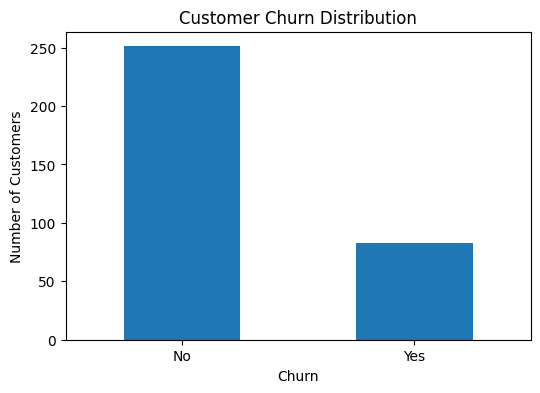

In [9]:
# ============================================================
# 9. EDA — CHURN DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))
final_data["churned"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

count    334.000000
mean       6.195851
std        2.535130
min       -0.461936
25%        4.383748
50%        6.203934
75%        8.003993
max       13.633959
Name: avg_logins_per_week, dtype: float64

Login outlier bounds:
Lower: -1.047
Upper: 13.434
Number of login outliers: 1


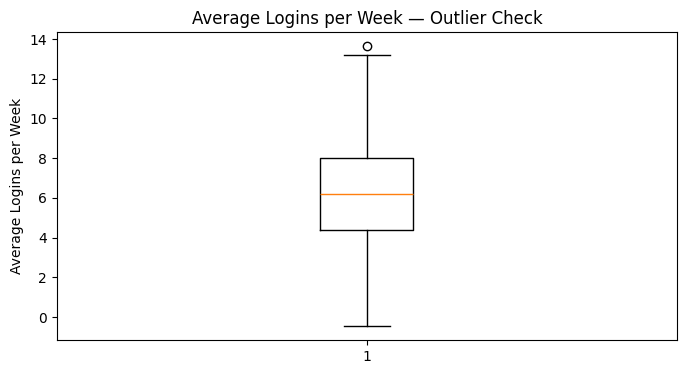

In [10]:
# ============================================================
# 10. EDA — LOGIN OUTLIER INVESTIGATION
# ============================================================

login_stats = final_data["avg_logins_per_week"].describe()
print(login_stats)

Q1 = final_data["avg_logins_per_week"].quantile(0.25)
Q3 = final_data["avg_logins_per_week"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

login_outliers = final_data[
    (final_data["avg_logins_per_week"] < lower_bound) |
    (final_data["avg_logins_per_week"] > upper_bound)
]

print("\nLogin outlier bounds:")
print("Lower:", round(lower_bound, 3))
print("Upper:", round(upper_bound, 3))
print("Number of login outliers:", len(login_outliers))

plt.figure(figsize=(8, 4))
plt.boxplot(final_data["avg_logins_per_week"].dropna())
plt.title("Average Logins per Week — Outlier Check")
plt.ylabel("Average Logins per Week")
plt.show()

churned
No     6.655997
Yes    4.804324
Name: avg_logins_per_week, dtype: float64


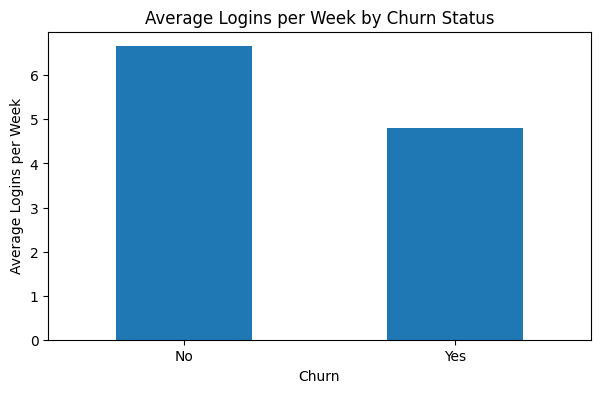

In [11]:
# ============================================================
# 11. EDA — LOGIN ACTIVITY VS CHURN
# ============================================================

login_by_churn = (
    final_data.groupby("churned")["avg_logins_per_week"]
    .mean()
)

print(login_by_churn)

plt.figure(figsize=(7, 4))
login_by_churn.plot(kind="bar")
plt.title("Average Logins per Week by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Logins per Week")
plt.xticks(rotation=0)
plt.show()

churned       No    Yes
plan_tier              
Business   71.82  28.18
Free       76.27  23.73
Pro        77.36  22.64


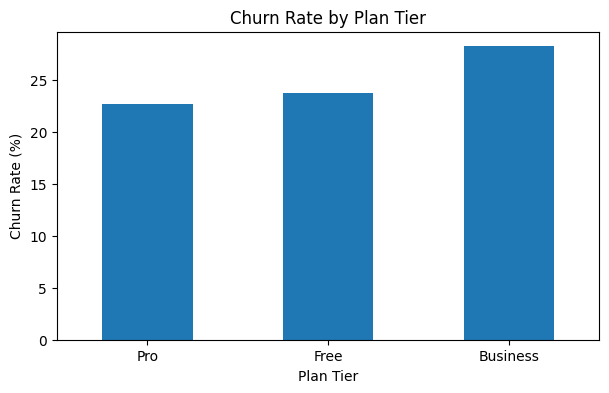

In [12]:
# ============================================================
# 12. EDA — CHURN RATE BY PLAN TIER
# ============================================================

plan_churn = pd.crosstab(
    final_data["plan_tier"],
    final_data["churned"],
    normalize="index"
) * 100

print(plan_churn.round(2))

if "Yes" in plan_churn.columns:
    plt.figure(figsize=(7, 4))
    plan_churn["Yes"].sort_values().plot(kind="bar")
    plt.title("Churn Rate by Plan Tier")
    plt.xlabel("Plan Tier")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()

In [13]:
# ============================================================
# 13. DEFINE MODEL FEATURES
# ============================================================

numeric_features = [
    "tenure_months",
    "avg_logins_per_week",
    "avg_feature_usage_score",
    "usage_log_count",
    "ticket_count",
    "avg_resolution_time_hours",
    "median_resolution_time_hours"
]

categorical_features = [
    "plan_tier",
    "region",
    "referral_source"
]

feature_columns = numeric_features + categorical_features

X = final_data[feature_columns].copy()

y = final_data["churned"].map({"No": 0, "Yes": 1})

print("Features used:")
print(feature_columns)

Features used:
['tenure_months', 'avg_logins_per_week', 'avg_feature_usage_score', 'usage_log_count', 'ticket_count', 'avg_resolution_time_hours', 'median_resolution_time_hours', 'plan_tier', 'region', 'referral_source']


In [14]:
# ============================================================
# 14. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("y_test distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (233, 10)
X_test : (101, 10)
y_train distribution:
churned
0    0.751
1    0.249
Name: proportion, dtype: float64
y_test distribution:
churned
0    0.752
1    0.248
Name: proportion, dtype: float64


In [15]:
# ============================================================
# 15. HANDLE LOGIN OUTLIERS USING TRAINING-SET IQR CAPS
# ============================================================

# Calculate IQR bounds only from the training data to avoid test-set leakage.
Q1_train = X_train["avg_logins_per_week"].quantile(0.25)
Q3_train = X_train["avg_logins_per_week"].quantile(0.75)
IQR_train = Q3_train - Q1_train

login_lower = Q1_train - 1.5 * IQR_train
login_upper = Q3_train + 1.5 * IQR_train

X_train = X_train.copy()
X_test = X_test.copy()

X_train["avg_logins_per_week"] = X_train["avg_logins_per_week"].clip(
    lower=login_lower, upper=login_upper
)

X_test["avg_logins_per_week"] = X_test["avg_logins_per_week"].clip(
    lower=login_lower, upper=login_upper
)

print("Login outlier treatment:")
print("Training IQR lower bound:", round(login_lower, 3))
print("Training IQR upper bound:", round(login_upper, 3))
print("Outliers are capped to these bounds for model training/testing.")


Login outlier treatment:
Training IQR lower bound: -1.386
Training IQR upper bound: 14.07
Outliers are capped to these bounds for model training/testing.


In [16]:
# ============================================================
# 16. PREPROCESSING PIPELINES
# ============================================================

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [17]:
# ============================================================
# 17. BASELINE MODEL
# ============================================================

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("========== BASELINE ==========")
print(classification_report(
    y_test,
    baseline_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== BASELINE ==========
              precision    recall  f1-score   support

    No Churn       0.75      1.00      0.86        76
       Churn       0.00      0.00      0.00        25

    accuracy                           0.75       101
   macro avg       0.38      0.50      0.43       101
weighted avg       0.57      0.75      0.65       101



In [18]:
# ============================================================
# 18. KNN — BASELINE CANDIDATE
# ============================================================

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
knn_pred = knn_pipeline.predict(X_test)

print("========== KNN ==========")
print(classification_report(
    y_test,
    knn_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== KNN ==========
              precision    recall  f1-score   support

    No Churn       0.78      0.89      0.83        76
       Churn       0.43      0.24      0.31        25

    accuracy                           0.73       101
   macro avg       0.61      0.57      0.57       101
weighted avg       0.69      0.73      0.70       101



c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\subp

In [19]:
# ============================================================
# 19. BALANCED LOGISTIC REGRESSION
# ============================================================

balanced_logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

balanced_logistic_pipeline.fit(X_train, y_train)
balanced_logistic_pred = balanced_logistic_pipeline.predict(X_test)

print("========== BALANCED LOGISTIC REGRESSION ==========")
print(classification_report(
    y_test,
    balanced_logistic_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== BALANCED LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

    No Churn       0.81      0.61      0.69        76
       Churn       0.32      0.56      0.41        25

    accuracy                           0.59       101
   macro avg       0.56      0.58      0.55       101
weighted avg       0.69      0.59      0.62       101



In [20]:
# ============================================================
# 20. RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("========== RANDOM FOREST ==========")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

    No Churn       0.76      0.96      0.85        76
       Churn       0.40      0.08      0.13        25

    accuracy                           0.74       101
   macro avg       0.58      0.52      0.49       101
weighted avg       0.67      0.74      0.67       101




KNN confusion matrix:
[[68  8]
 [19  6]]


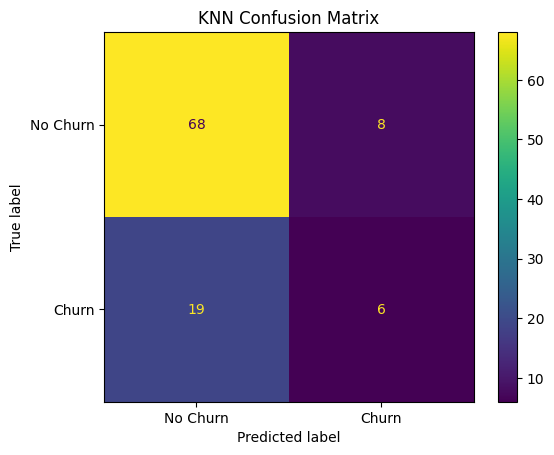


Balanced Logistic Regression confusion matrix:
[[46 30]
 [11 14]]


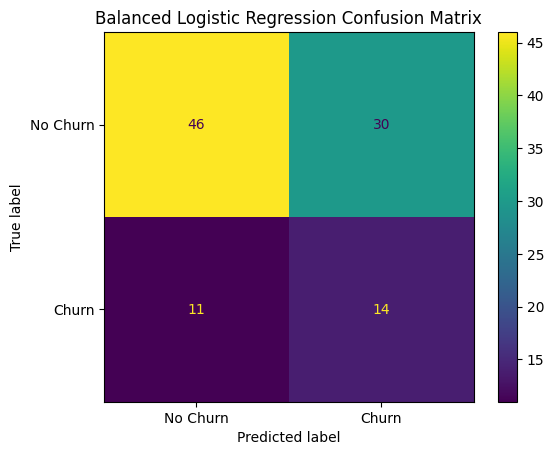


Random Forest confusion matrix:
[[73  3]
 [23  2]]


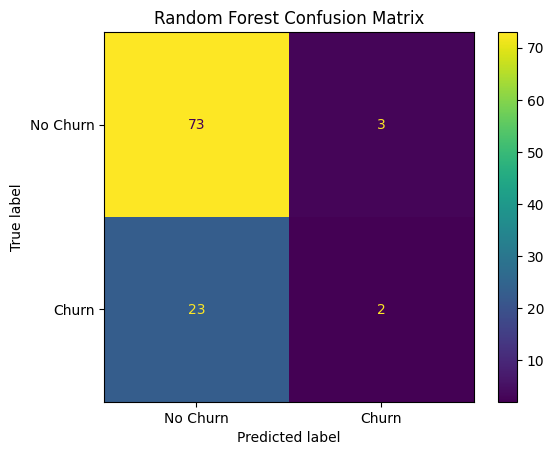

In [21]:
# ============================================================
# 21. CONFUSION MATRICES — CANDIDATE MODELS
# ============================================================

model_predictions = {
    "KNN": knn_pred,
    "Balanced Logistic Regression": balanced_logistic_pred,
    "Random Forest": rf_pred
}

for name, pred in model_predictions.items():
    cm = confusion_matrix(y_test, pred)
    print(f"\n{name} confusion matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [22]:
# ============================================================
# 22. HOLD-OUT MODEL COMPARISON
# ============================================================

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Churn Precision": precision_score(y_true, y_pred, zero_division=0),
        "Churn Recall": recall_score(y_true, y_pred, zero_division=0),
        "Churn F1": f1_score(y_true, y_pred, zero_division=0)
    }

comparison_rows = []
for name, pred in model_predictions.items():
    row = {"Model": name}
    row.update(get_metrics(y_test, pred))
    comparison_rows.append(row)

model_results = pd.DataFrame(comparison_rows).sort_values(
    by="Churn F1",
    ascending=False
).reset_index(drop=True)

print(model_results.round(3))

                          Model  Accuracy  Churn Precision  Churn Recall  \
0  Balanced Logistic Regression     0.594            0.318          0.56   
1                           KNN     0.733            0.429          0.24   
2                 Random Forest     0.743            0.400          0.08   

   Churn F1  
0     0.406  
1     0.308  
2     0.133  


In [23]:
# ============================================================
# 23. 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_models = {
    "KNN": knn_pipeline,
    "Balanced Logistic Regression": balanced_logistic_pipeline,
    "Random Forest": rf_pipeline
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_rows = []

for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    by="CV F1",
    ascending=False
).reset_index(drop=True)

print("========== 5-FOLD CROSS-VALIDATION ==========")
print(cv_results.round(3))

========== 5-FOLD CROSS-VALIDATION ==========
                          Model  CV Accuracy  CV Precision  CV Recall  CV F1
0  Balanced Logistic Regression        0.678         0.418      0.658  0.505
1                           KNN        0.704         0.287      0.153  0.197
2                 Random Forest        0.729         0.310      0.120  0.172


In [24]:
# ============================================================
# 24. HYPERPARAMETER TUNING — KNN
# ============================================================

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    refit=True
)

knn_search.fit(X_train, y_train)

tuned_knn = knn_search.best_estimator_

tuned_knn_pred = tuned_knn.predict(X_test)

print("Best KNN parameters:")
print(knn_search.best_params_)
print("Best CV Churn F1:", round(knn_search.best_score_, 3))

Best KNN parameters:
{'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'uniform'}
Best CV Churn F1: 0.272


In [25]:
# ============================================================
# 25. HYPERPARAMETER TUNING — BALANCED LOGISTIC REGRESSION
# ============================================================

logistic_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_search = GridSearchCV(
    estimator=balanced_logistic_pipeline,
    param_grid=logistic_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    refit=True
)

logistic_search.fit(X_train, y_train)

tuned_logistic = logistic_search.best_estimator_
tuned_logistic_pred = tuned_logistic.predict(X_test)

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)
print("Best CV Churn F1:", round(logistic_search.best_score_, 3))

Best Logistic Regression parameters:
{'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV Churn F1: 0.539


In [26]:
# ============================================================
# 26. HYPERPARAMETER TUNING — RANDOM FOREST
# ============================================================

# RandomizedSearchCV keeps tuning practical for a small project
# while still testing multiple Random Forest hyperparameters.
rf_param_distributions = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=8,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True
)

rf_search.fit(X_train, y_train)

tuned_rf = rf_search.best_estimator_
tuned_rf_pred = tuned_rf.predict(X_test)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV Churn F1:", round(rf_search.best_score_, 3))


Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 5}
Best CV Churn F1: 0.464


In [27]:
# ============================================================
# 27. TUNED MODEL COMPARISON
# ============================================================

tuned_models = {
    "Tuned KNN": tuned_knn_pred,
    "Tuned Balanced Logistic Regression": tuned_logistic_pred,
    "Tuned Random Forest": tuned_rf_pred
}

tuned_rows = []
for name, pred in tuned_models.items():
    row = {"Model": name}
    row.update(get_metrics(y_test, pred))
    tuned_rows.append(row)

tuned_results = pd.DataFrame(tuned_rows).sort_values(
    by="Churn F1",
    ascending=False
).reset_index(drop=True)

print("========== TUNED MODEL COMPARISON ==========")
print(tuned_results.round(3))

========== TUNED MODEL COMPARISON ==========
                                Model  Accuracy  Churn Precision  \
0  Tuned Balanced Logistic Regression     0.624            0.356   
1                           Tuned KNN     0.762            0.526   
2                 Tuned Random Forest     0.663            0.333   

   Churn Recall  Churn F1  
0          0.64     0.457  
1          0.40     0.455  
2          0.36     0.346  


In [28]:
# ============================================================
# 28. FINAL MODEL SELECTION
# ============================================================

# The assignment is a churn-detection problem with class imbalance.
# Therefore, Churn F1 is used as the main selection criterion rather than accuracy alone.

final_candidates = pd.DataFrame({
    "Model": [
        "Tuned KNN",
        "Tuned Balanced Logistic Regression",
        "Tuned Random Forest"
    ],
    "CV Churn F1": [
        knn_search.best_score_,
        logistic_search.best_score_,
        rf_search.best_score_
    ]
}).sort_values("CV Churn F1", ascending=False).reset_index(drop=True)

print("========== FINAL MODEL SELECTION ==========")
print(final_candidates.round(3))

best_model_name = final_candidates.iloc[0]["Model"]

if best_model_name == "Tuned KNN":
    final_model = tuned_knn
    final_model_pred = tuned_knn_pred
elif best_model_name == "Tuned Balanced Logistic Regression":
    final_model = tuned_logistic
    final_model_pred = tuned_logistic_pred
else:
    final_model = tuned_rf
    final_model_pred = tuned_rf_pred

print("\nSelected final model:", best_model_name)
print("\nFinal model hold-out evaluation:")
print(classification_report(
    y_test,
    final_model_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

========== FINAL MODEL SELECTION ==========
                                Model  CV Churn F1
0  Tuned Balanced Logistic Regression        0.539
1                 Tuned Random Forest        0.464
2                           Tuned KNN        0.272

Selected final model: Tuned Balanced Logistic Regression

Final model hold-out evaluation:
              precision    recall  f1-score   support

    No Churn       0.84      0.62      0.71        76
       Churn       0.36      0.64      0.46        25

    accuracy                           0.62       101
   macro avg       0.60      0.63      0.58       101
weighted avg       0.72      0.62      0.65       101



[[47 29]
 [ 9 16]]


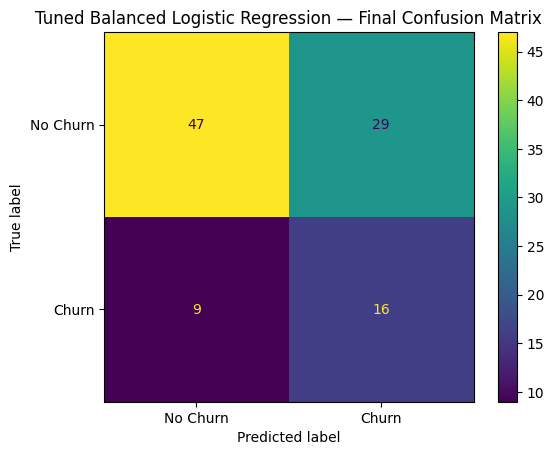

In [29]:
# ============================================================
# 29. FINAL MODEL CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(y_test, final_model_pred)
print(final_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title(f"{best_model_name} — Final Confusion Matrix")
plt.show()

In [30]:
# ============================================================
# 30. FEATURE IMPORTANCE / COEFFICIENTS WHEN AVAILABLE
# ============================================================

if "Random Forest" in best_model_name:
    fitted_preprocessor = final_model.named_steps["preprocessor"]
    fitted_rf = final_model.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_rf.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("========== RANDOM FOREST FEATURE IMPORTANCE ==========")
    print(feature_importance.head(20))

    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(15).sort_values("Importance")
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title("Top Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Final model is not Random Forest; feature importance is not displayed in tree-importance form.")

Final model is not Random Forest; feature importance is not displayed in tree-importance form.


In [31]:
# ============================================================
# 31. BUILD ONE CONSISTENT FEATURE TABLE FOR NEW CUSTOMERS
# ============================================================

prediction_data = churned_to_predict[["account_id"]].copy()

prediction_data = (
    prediction_data
    .merge(
        account_master[
            ["account_id", "plan_tier", "tenure_months", "region", "referral_source"]
        ],
        on="account_id",
        how="left",
        validate="one_to_one"
    )
    .merge(usage_summary, on="account_id", how="left", validate="one_to_one")
    .merge(ticket_summary, on="account_id", how="left", validate="one_to_one")
)

# Same semantic missing-value handling used for training data.
for col in usage_cols + ticket_count_cols + ticket_time_cols:
    prediction_data[col] = prediction_data[col].fillna(0)

for col in ["plan_tier", "region", "referral_source"]:
    prediction_data[col] = prediction_data[col].fillna("Unknown")

# Apply the same login outlier caps learned from the training data.
prediction_data["avg_logins_per_week"] = prediction_data["avg_logins_per_week"].clip(
    lower=login_lower, upper=login_upper
)

X_new = prediction_data[feature_columns].copy()

print("Training feature columns:")
print(X_train.columns.tolist())

print("\nPrediction feature columns:")
print(X_new.columns.tolist())

if X_train.columns.tolist() != X_new.columns.tolist():
    raise ValueError("Training and prediction feature columns do not match.")

print("\nFeature names match successfully.")
print("Prediction data shape:", X_new.shape)
print(X_new.head())

Training feature columns:
['tenure_months', 'avg_logins_per_week', 'avg_feature_usage_score', 'usage_log_count', 'ticket_count', 'avg_resolution_time_hours', 'median_resolution_time_hours', 'plan_tier', 'region', 'referral_source']

Prediction feature columns:
['tenure_months', 'avg_logins_per_week', 'avg_feature_usage_score', 'usage_log_count', 'ticket_count', 'avg_resolution_time_hours', 'median_resolution_time_hours', 'plan_tier', 'region', 'referral_source']

Feature names match successfully.
Prediction data shape: (58, 10)
   tenure_months  avg_logins_per_week  avg_feature_usage_score  \
0             59             5.677078                 4.396709   
1             25             3.845271                 3.878719   
2             12             5.486593                 4.413497   
3              7             2.043062                 2.749750   
4              4             9.043588                 7.286863   

   usage_log_count  ticket_count  avg_resolution_time_hours  \
0     

In [32]:
# ============================================================
# 32. FINAL CHURN PREDICTIONS
# ============================================================

final_prediction = final_model.predict(X_new)

final_predictions = churned_to_predict[["account_id"]].copy()
final_predictions["Predicted_Churn"] = np.where(
    final_prediction == 1,
    "Churn",
    "No Churn"
)

print("========== FINAL CHURN PREDICTIONS ==========")
print(final_predictions)

print("\nPrediction Summary:")
print(final_predictions["Predicted_Churn"].value_counts())

========== FINAL CHURN PREDICTIONS ==========
   account_id Predicted_Churn
0   CUST-0029           Churn
1   CUST-0040           Churn
2   CUST-0041        No Churn
3   CUST-0042           Churn
4   CUST-0059        No Churn
5   CUST-0076           Churn
6   CUST-0082        No Churn
7   CUST-0083           Churn
8   CUST-0096        No Churn
9   CUST-0103        No Churn
10  CUST-0108           Churn
11  CUST-0118        No Churn
12  CUST-0119        No Churn
13  CUST-0132           Churn
14  CUST-0134        No Churn
15  CUST-0141           Churn
16  CUST-0143        No Churn
17  CUST-0157           Churn
18  CUST-0158        No Churn
19  CUST-0164        No Churn
20  CUST-0166        No Churn
21  CUST-0172        No Churn
22  CUST-0174           Churn
23  CUST-0178        No Churn
24  CUST-0219        No Churn
25  CUST-0230        No Churn
26  CUST-0232        No Churn
27  CUST-0243           Churn
28  CUST-0244        No Churn
29  CUST-0248           Churn
30  CUST-0252        No 

In [33]:
# ============================================================
# 33. SAVE FINAL PREDICTIONS
# ============================================================

output_file = "final_churn_predictions.csv"

final_predictions.to_csv(output_file, index=False)

print("Final predictions saved successfully!")
print("File:", output_file)

Final predictions saved successfully!
File: final_churn_predictions.csv


## Final Conclusion

The revised workflow addresses the faculty feedback by checking data quality before merging, using meaningful usage and support aggregations, retaining useful customer features, handling categorical and numerical missing values appropriately, investigating login outliers, evaluating precision/recall/F1, using stratified cross-validation, tuning KNN/Logistic Regression/Random Forest, including Balanced Logistic Regression in the comparison, and selecting the final model using cross-validated Churn F1 rather than accuracy alone.

The same feature-engineering workflow is reused for `churned_to_predict.csv`, so the previous `total_usage` vs `avg_logins_per_week` feature-name error is avoided.